# **Chargement du dataset et vue d’ensemble**

## 1. Import des librairies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

## 2. Chargement du fichier

In [3]:
from google.colab import files
uploaded = files.upload()

Saving bank-full.csv to bank-full.csv


In [4]:
src = "bank-full.csv"
df = pd.read_csv(src, sep=";")

## 3. Aperçu des premières lignes

In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Interprétation de `df.head()`

## 1. Structure générale des données

Le tableau affiche les **5 premières observations du dataset**.
Chaque ligne représente **un client contacté lors d’une campagne marketing téléphonique menée par la banque**.

Chaque colonne correspond à **une caractéristique du client ou de l’interaction avec la banque**.

On observe **17 variables au total**, dont la variable cible `y`.

## 2. Types de variables observées

On peut déjà identifier deux grandes catégories de variables.

### Variables numériques

Ces variables contiennent des valeurs quantitatives :

* **age** : âge du client
* **balance** : solde du compte bancaire
* **day** : jour du mois du contact
* **duration** : durée de l’appel téléphonique (en secondes)
* **campaign** : nombre de contacts effectués pendant la campagne actuelle
* **pdays** : nombre de jours depuis le dernier contact avec le client
* **previous** : nombre de contacts effectués avant cette campagne

### Variables catégorielles

Ces variables représentent des catégories :

* **job** : profession du client
* **marital** : statut marital
* **education** : niveau d’éducation
* **default** : défaut de paiement
* **housing** : prêt immobilier
* **loan** : prêt personnel
* **contact** : type de communication utilisé
* **month** : mois du dernier contact
* **poutcome** : résultat de la campagne marketing précédente

### Variable cible

**y**

Elle indique si le client a **souscrit au produit d’épargne proposé par la banque**.

Valeurs possibles :

* `yes`
* `no`

C’est **la variable que nous chercherons à expliquer et à prédire**.

## 3. Premières observations intéressantes

On peut déjà remarquer quelques éléments :

### Présence de valeurs `unknown`

Certaines variables contiennent la modalité **`unknown`**, par exemple :

* `education`
* `job`
* `contact`
* `poutcome`

Cela signifie que **l'information n'est pas disponible pour certains clients**.

Cette observation est importante car ces valeurs devront être **analysées ou traitées lors du nettoyage des données**.

### Valeur particulière dans `pdays`

On remarque que `pdays = -1` pour les premières observations.

Dans ce dataset, cette valeur signifie généralement :

> le client **n'a jamais été contacté lors d’une campagne précédente**.

Cette variable sera intéressante pour analyser **l’effet de l’historique de contact sur la probabilité de souscription**.

## 4. Première compréhension du dataset

À ce stade, on peut dire que le dataset contient :

* des **caractéristiques socio-démographiques des clients** (âge, profession, éducation)
* des **informations financières** (balance, prêts)
* des **informations liées à la campagne marketing** (durée d’appel, nombre de contacts, résultat précédent)

Ces informations permettront d’analyser :

* **les profils de clients les plus susceptibles de souscrire**
* **les facteurs qui influencent la réussite d’une campagne marketing**.




In [6]:
df.shape

(45211, 17)

## Interprétation de `df.shape`

Résultat obtenu :

```
(45211, 17)
```

### 1. Taille du dataset

Le dataset contient :

* **45 211 observations (lignes)**
* **17 variables (colonnes)**

Chaque ligne correspond à **un client contacté lors d’une campagne marketing téléphonique menée par la banque**.

Cela signifie que l’analyse porte sur **plus de 45 000 interactions client**, ce qui constitue un volume de données suffisant pour réaliser :

* une analyse exploratoire fiable
* des analyses statistiques pertinentes
* l’entraînement de modèles de machine learning robustes.

### 2. Nombre de variables

Les **17 variables** décrivent différents aspects liés :

1. **au profil du client**
2. **à sa situation financière**
3. **à l’historique de contact avec la banque**
4. **à la campagne marketing actuelle**

Parmi ces variables, **une est la variable cible** :

```
y
```

Elle indique si le client a **souscrit (`yes`) ou non (`no`) au produit d’épargne proposé**.

Les **16 autres variables** sont des variables explicatives susceptibles d’influencer cette décision.

### 3. Première conclusion sur la structure du dataset

Ce dataset présente une structure adaptée à un problème de **classification supervisée** :

* les **variables explicatives** décrivent les caractéristiques des clients et des campagnes
* la **variable cible binaire (`yes/no`)** représente la décision finale du client.

L’objectif du projet sera donc d’identifier **quels facteurs influencent la souscription au produit d’épargne** et de construire des modèles capables **de prédire cette décision**.

### 4. Intérêt de la taille du dataset

Avec plus de **45 000 observations**, ce dataset présente plusieurs avantages :

* réduction du risque de surapprentissage
* meilleure représentativité des profils clients
* possibilité de tester plusieurs modèles de machine learning.

Cependant, un dataset de cette taille peut également présenter :

* des **déséquilibres dans la variable cible**
* des **modalités rares dans certaines variables catégorielles**

Ces aspects devront être vérifiés dans les étapes suivantes de l’analyse exploratoire.

In [7]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


## 1. Vérification des valeurs manquantes

La colonne **Non-Null Count** indique que toutes les variables contiennent :

```
45211 non-null values
```

Cela signifie que **le dataset ne contient pas de valeurs manquantes explicites (NaN)**.

C’est un point positif car :

* il n’y a pas besoin d’imputation de valeurs manquantes
* toutes les observations sont exploitables pour l’analyse.

Cependant, certaines variables contiennent la modalité **"unknown"**, qui peut représenter **une information manquante ou inconnue**.
Ces valeurs devront être étudiées lors de l’analyse exploratoire.


# 2. Types de variables

Le dataset contient **deux types de variables** :

### Variables numériques (`int64`) : 7

```
age
balance
day
duration
campaign
pdays
previous
```

Ces variables représentent des **quantités mesurables** liées :

* au profil du client
* à son historique avec la banque
* à la campagne marketing.

Par exemple :

* `age` : âge du client
* `balance` : solde du compte bancaire
* `duration` : durée de l’appel téléphonique
* `campaign` : nombre de contacts durant la campagne.


### Variables catégorielles (`object`) : 10

```
job
marital
education
default
housing
loan
contact
month
poutcome
y
```

Ces variables représentent **des catégories ou modalités** décrivant :

* la situation socio-démographique du client
* sa situation financière
* le contexte de la campagne marketing.

Par exemple :

* `job` : profession
* `marital` : statut marital
* `education` : niveau d’éducation
* `housing` : prêt immobilier
* `loan` : prêt personnel.


# 3. Variable cible

La variable :

```
y
```

est une variable **catégorielle binaire** :

* `yes` → le client a souscrit au produit
* `no` → le client n’a pas souscrit.

Cette variable constitue **la cible du problème de classification**.

L’objectif du projet sera donc :

* d’identifier les facteurs influençant cette décision
* de construire des modèles capables de **prédire la probabilité de souscription**.


In [9]:
df.nunique()
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

job ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
marital ['married' 'single' 'divorced']
education ['tertiary' 'secondary' 'unknown' 'primary']
default ['no' 'yes']
housing ['yes' 'no']
loan ['no' 'yes']
contact ['unknown' 'cellular' 'telephone']
month ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
poutcome ['unknown' 'failure' 'other' 'success']
y ['no' 'yes']


# Analyse des modalités des variables catégorielles

L’exploration des variables catégorielles permet d’identifier **les différentes catégories présentes dans le dataset** ainsi que certaines valeurs particulières comme **"unknown"**, qui peuvent représenter une information manquante.


# 1. Variable **job**

Modalités observées :

```
management, technician, entrepreneur, blue-collar,
retired, admin., services, self-employed,
unemployed, housemaid, student, unknown
```

Cette variable décrit **la profession du client**.

On observe **plusieurs catégories socio-professionnelles**, ce qui permettra d’étudier si certains profils professionnels sont **plus susceptibles de souscrire au produit d’épargne**.

La présence de la modalité **"unknown"** indique que l’information sur la profession n’est pas disponible pour certains clients.


# 2. Variable **marital**

Modalités :

```
married, single, divorced
```

Cette variable représente **le statut marital du client**.

Elle pourra permettre d’analyser si la situation familiale influence la décision de souscription.

Par exemple, il est possible que **les clients mariés présentent des comportements d’épargne différents**.


# 3. Variable **education**

Modalités :

```
tertiary, secondary, primary, unknown
```

Cette variable indique **le niveau d’éducation du client**.

La présence de la modalité **"unknown"** montre que cette information n’est pas renseignée pour certains individus.

Cette variable pourrait être intéressante pour analyser si **le niveau d’éducation influence la décision financière**.


# 4. Variables liées à la situation financière

Certaines variables décrivent **la situation financière du client**.

### default

```
yes / no
```

Indique si le client a **déjà eu un défaut de paiement**.


### housing

```
yes / no
```

Indique si le client possède **un prêt immobilier**.


### loan

```
yes / no
```

Indique si le client possède **un prêt personnel**.

Ces variables pourraient influencer la probabilité de souscription, car **la capacité d’épargne peut dépendre du niveau d’endettement du client**.


# 5. Variable **contact**

Modalités :

```
cellular, telephone, unknown
```

Cette variable indique **le type de communication utilisé pour contacter le client**.

Cela permettra d’analyser si **le canal de communication influence la réussite de la campagne marketing**.

La présence de **"unknown"** suggère que l’information n’est pas disponible dans certains cas.


# 6. Variable **month**

Modalités :

```
jan, feb, mar, apr, may, jun, jul, aug, sep, oct, nov, dec
```

Cette variable indique **le mois durant lequel le contact avec le client a eu lieu**.

Elle peut révéler **une saisonnalité dans la réussite des campagnes marketing**.

Par exemple, certaines périodes de l’année peuvent être **plus favorables à l’épargne**.

# 7. Variable **poutcome**

Modalités :

```
success, failure, other, unknown
```

Cette variable correspond **au résultat de la campagne marketing précédente**.

Elle est particulièrement intéressante car elle permet d’analyser **l’influence de l’historique des campagnes sur le comportement des clients**.

Par exemple :

* un client ayant déjà répondu positivement pourrait être **plus susceptible de souscrire à nouveau**.


# 8. Variable cible **y**

Modalités :

```
yes, no
```

Cette variable indique si le client **a souscrit ou non au produit d’épargne proposé**.

Elle constitue **la variable cible du projet**, et sera utilisée pour :

* analyser les facteurs influençant la souscription
* entraîner des modèles de classification.


# Observation importante : présence de "unknown"

Plusieurs variables contiennent la modalité **"unknown"**, notamment :

* job
* education
* contact
* poutcome

Ces valeurs peuvent correspondre :

* à une information réellement inconnue
* à une donnée non renseignée.

Il sera important d’analyser leur fréquence afin de déterminer **si elles doivent être conservées comme une catégorie ou traitées différemment lors du prétraitement**.


# Conclusion de cette étape

L’analyse des modalités montre que le dataset contient **une grande diversité de variables catégorielles décrivant les caractéristiques socio-économiques des clients ainsi que le contexte des campagnes marketing**.

Ces variables permettront d’identifier **les profils de clients les plus susceptibles de répondre positivement à une campagne marketing bancaire**.


In [10]:
# Maintenant on va analyser la variable cible, car c’est elle qui structure toute l’analyse.

df['y'].value_counts()
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.883015
yes,0.116985


# Analyse de la variable cible `y`

La variable `y` représente **la décision finale du client concernant la souscription au produit d’épargne proposé par la banque**.

Elle possède deux modalités :

* **yes** : le client a souscrit au produit
* **no** : le client n’a pas souscrit


# 1. Répartition des classes

Les résultats obtenus montrent :

| Classe | Proportion |
| ------ | ---------- |
| no     | **88.3 %** |
| yes    | **11.7 %** |

Cela signifie que **la grande majorité des clients contactés n'ont pas souscrit au produit d’épargne**.

Autrement dit :

* environ **9 clients sur 10 refusent l’offre**
* seulement **1 client sur 10 accepte**.


# 2. Déséquilibre des classes

Cette distribution met en évidence **un déséquilibre important entre les classes**.

On parle de **dataset déséquilibré (imbalanced dataset)**.

Dans ce cas :

* la classe **"no"** est largement dominante
* la classe **"yes"** est minoritaire.

Ce type de situation est fréquent dans les campagnes marketing : la majorité des clients **ne répondent pas positivement aux sollicitations commerciales**.


# 3. Implications pour l’analyse

Ce déséquilibre est un point important pour plusieurs raisons.

### A. Interprétation des résultats

Lors de l’analyse exploratoire, il faudra être attentif aux variables qui **augmentent la probabilité de souscription**, car la classe positive est relativement rare.



### B. Modélisation

Dans un problème de classification déséquilibré :

* un modèle pourrait obtenir **une forte accuracy simplement en prédisant toujours "no"**.

Par exemple :

Si un modèle prédit toujours **"no"**, il aurait déjà **88 % d’accuracy**, sans réellement apprendre des données.

C’est pourquoi il sera important d’utiliser **des métriques adaptées**, comme :

* **precision**
* **recall**
* **F1-score**
* **ROC-AUC**

plutôt que de se limiter à l’accuracy.


# 4. Interprétation métier

Du point de vue marketing, ce résultat signifie que :

* les campagnes téléphoniques ont **un taux de conversion relativement faible**
* il est donc stratégique d’identifier **les profils de clients les plus susceptibles de souscrire**, afin d’optimiser les efforts commerciaux.

L’objectif de l’analyse sera donc de **comprendre quels facteurs augmentent la probabilité de souscription**, afin d’améliorer l’efficacité des campagnes futures.


# Conclusion de cette étape

L’analyse de la variable cible montre que :

* la souscription au produit d’épargne est **relativement rare dans le dataset**
* les données présentent **un déséquilibre important entre les classes**
* ce déséquilibre devra être pris en compte lors de la modélisation et de l’évaluation des modèles.


In [11]:
# Maintenant que la variable cible est comprise, on va commencer la véritable analyse des variables explicatives.
# La première étape consiste à analyser les variables numériques.

df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


# Analyse descriptive des variables numériques

Les variables numériques étudiées sont :

* `age`
* `balance`
* `day`
* `duration`
* `campaign`
* `pdays`
* `previous`

Chaque variable est décrite par :

* moyenne (`mean`)
* écart-type (`std`)
* minimum
* quartiles (25 %, 50 %, 75 %)
* maximum.


# 1. Variable **age**

Statistiques principales :

* moyenne : **40.9 ans**
* médiane : **39 ans**
* minimum : **18 ans**
* maximum : **95 ans**

### Interprétation

La majorité des clients se situe autour de **40 ans**, ce qui correspond à une population adulte active.

L’écart entre les quartiles :

* 25 % → **33 ans**
* 75 % → **48 ans**

montre que **la moitié des clients ont entre 33 et 48 ans**.

La présence d’âges élevés (jusqu’à 95 ans) peut correspondre à **des clients retraités**, mais ces valeurs restent plausibles et ne semblent pas aberrantes.


# 2. Variable **balance**

Statistiques principales :

* moyenne : **1362**
* médiane : **448**
* minimum : **-8019**
* maximum : **102127**

### Interprétation

Le solde moyen des comptes est d’environ **1362 unités monétaires**.

Cependant, on observe :

* une **médiane nettement plus faible que la moyenne**
* une valeur maximale très élevée.

Cela indique une **distribution asymétrique (skewed)** : quelques clients possèdent **des soldes très élevés**, ce qui tire la moyenne vers le haut.

La présence de soldes négatifs (minimum **-8019**) signifie que certains clients sont **à découvert**, ce qui peut être un facteur influençant leur comportement d’épargne.


# 3. Variable **day**

Statistiques :

* minimum : **1**
* maximum : **31**
* moyenne : **15.8**

### Interprétation

Cette variable correspond **au jour du mois où le client a été contacté**.

Sa distribution est relativement uniforme entre **1 et 31**, ce qui est logique puisque les campagnes peuvent être réalisées tout au long du mois.

Cette variable pourrait révéler **un effet temporel**, par exemple si certains jours du mois influencent la probabilité de réponse.

# 4. Variable **duration**

Statistiques principales :

* moyenne : **258 secondes**
* médiane : **180 secondes**
* maximum : **4918 secondes**

### Interprétation

La durée moyenne des appels est d’environ **4 minutes**.

Cependant, certaines conversations peuvent durer **plus de 80 minutes**, ce qui explique la valeur maximale élevée.

La durée d’appel est souvent **très corrélée avec la réussite de la campagne**, car un client intéressé aura tendance à prolonger la conversation.

Cependant, cette variable doit être utilisée avec précaution, car elle n’est connue **qu’après l’appel**.


# 5. Variable **campaign**

Statistiques principales :

* moyenne : **2.76**
* médiane : **2**
* maximum : **63**

### Interprétation

Cette variable indique **le nombre de contacts réalisés avec le client pendant la campagne actuelle**.

La majorité des clients sont contactés **entre 1 et 3 fois**, ce qui est cohérent avec une stratégie commerciale raisonnable.

Cependant, certaines observations montrent jusqu’à **63 contacts**, ce qui peut correspondre à des cas particuliers ou à des tentatives répétées de contact.


# 6. Variable **pdays**

Statistiques principales :

* minimum : **-1**
* maximum : **871**
* moyenne : **40**

### Interprétation

Cette variable représente **le nombre de jours depuis le dernier contact avec le client lors d’une campagne précédente**.

La valeur **-1** indique que **le client n’a jamais été contacté auparavant**.

On observe que les quartiles sont également à **-1**, ce qui suggère qu’une grande proportion des clients **n’a jamais participé à une campagne précédente**.

Cette variable pourrait être importante pour analyser **l’effet de l’historique marketing sur la probabilité de souscription**.


# 7. Variable **previous**

Statistiques principales :

* moyenne : **0.58**
* médiane : **0**
* maximum : **275**

### Interprétation

Cette variable correspond **au nombre de contacts effectués avec le client avant la campagne actuelle**.

La médiane égale à **0** indique que **la majorité des clients n’ont jamais été contactés auparavant**.

Cependant, certains clients ont été contactés **de nombreuses fois**, ce qui peut refléter une stratégie de suivi pour certains profils spécifiques.

# Conclusion de l’analyse des variables numériques

L’analyse descriptive montre que :

* les clients ont en moyenne **environ 41 ans**
* les soldes bancaires présentent **une forte variabilité**
* la plupart des clients sont contactés **peu de fois par campagne**
* une grande proportion des clients **n’a jamais été contactée auparavant**.

Ces variables pourraient jouer un rôle important dans la compréhension du comportement de souscription.

Maintenant, on va analyser la distribution visuelle des variables numériques pour détecter :

*   asymétries
*   outliers
*   formes de distribution.

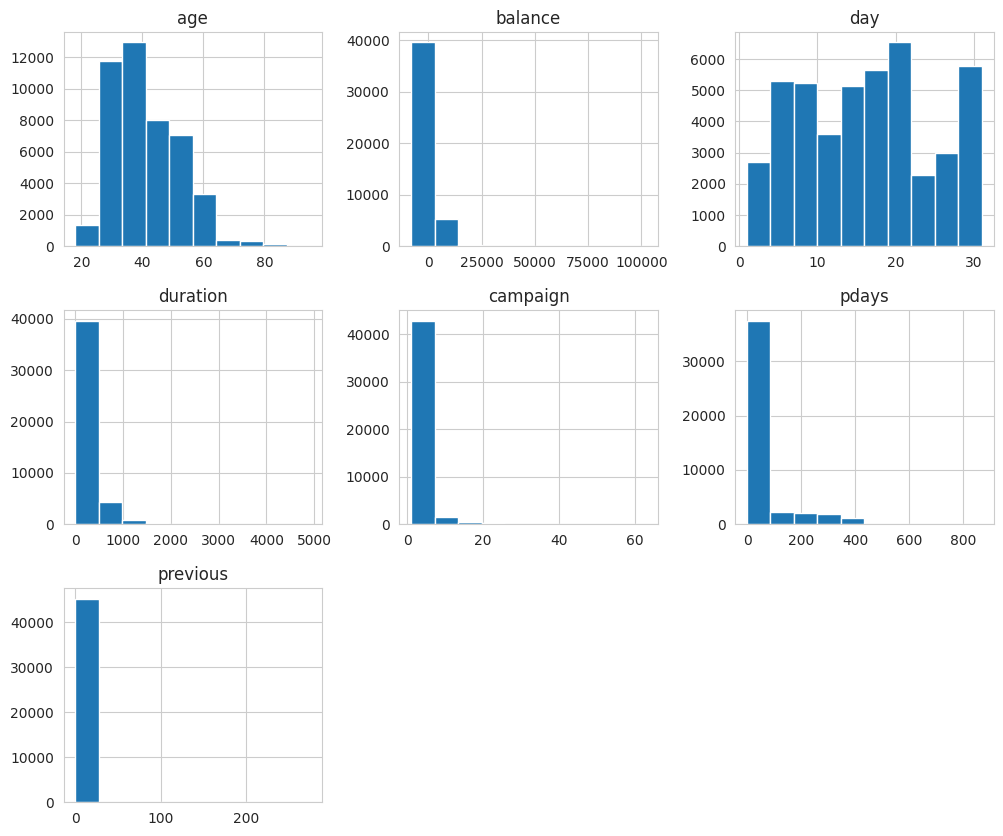

In [12]:
df.hist(figsize=(12,10))
plt.show()

# Analyse des distributions des variables numériques

## 1. Distribution de l’âge (`age`)

L’histogramme montre une distribution relativement **centrée entre 30 et 50 ans**.

* La majorité des clients se situe dans cette tranche d’âge.
* Les clients très jeunes (moins de 25 ans) ou très âgés (plus de 70 ans) sont peu nombreux.

La distribution semble **légèrement asymétrique vers la droite**, avec quelques valeurs élevées correspondant probablement à des clients retraités.

**Interprétation possible :**
La base client de la banque est majoritairement composée **d’adultes en âge d’activité professionnelle**, ce qui est cohérent avec une population susceptible d’avoir une activité bancaire régulière.

## 2. Distribution du solde bancaire (`balance`)

La distribution du solde est **très asymétrique (skewed à droite)**.

On observe :

* une forte concentration de clients avec un solde relativement faible
* quelques valeurs extrêmement élevées.

Cela indique la présence **d’outliers importants**, c’est-à-dire des clients possédant des soldes très élevés.

**Interprétation :**

* la majorité des clients possède un solde modéré
* une petite proportion de clients détient des soldes très élevés, ce qui explique la moyenne relativement élevée observée précédemment.


## 3. Distribution du jour du contact (`day`)

La variable `day` présente une distribution **relativement répartie entre 1 et 31**.

On observe cependant quelques variations dans la fréquence des contacts selon les jours.

**Interprétation :**

Les campagnes marketing semblent être réalisées **tout au long du mois**, sans concentration extrême sur un jour particulier.

Cette variable pourrait toutefois révéler **de légères différences d’efficacité selon le moment du mois**.


## 4. Distribution de la durée des appels (`duration`)

La distribution de `duration` est **fortement asymétrique à droite**.

La majorité des appels sont **relativement courts**, mais quelques appels durent très longtemps.

Cela suggère que :

* la plupart des conversations sont rapides
* certains appels correspondent probablement à **des clients réellement intéressés**, ce qui prolonge la discussion.

**Remarque importante :**

La durée de l’appel est souvent **un facteur très fortement corrélé avec la souscription**, car un client intéressé aura tendance à discuter plus longtemps.

Cependant, cette variable doit être utilisée avec prudence car elle **n’est connue qu’après l’appel**.


## 5. Distribution du nombre de contacts pendant la campagne (`campaign`)

La distribution montre que :

* la grande majorité des clients est contactée **1 à 3 fois**
* les valeurs élevées sont rares.

On observe quelques cas extrêmes où certains clients ont été contactés **plus de 20 fois**, voire plus.

**Interprétation :**

La stratégie commerciale semble généralement limiter le nombre de tentatives de contact, mais certains cas particuliers peuvent faire l’objet **d’un suivi intensif**.


## 6. Distribution de `pdays`

La distribution est très particulière :

* une très forte concentration autour de **-1**
* quelques valeurs positives allant jusqu’à **plusieurs centaines de jours**.

Cela confirme que **la majorité des clients n’a jamais été contactée lors d’une campagne précédente**.

Les valeurs positives correspondent aux clients **ayant déjà participé à une campagne marketing passée**.


## 7. Distribution de `previous`

La distribution montre que :

* la grande majorité des observations est **égale à 0**
* quelques clients ont été contactés plusieurs fois auparavant.

Cela indique que **la plupart des clients n’ont pas d’historique de campagne marketing avec la banque**.


# Conclusion de l’analyse des distributions

L’exploration visuelle des variables numériques met en évidence plusieurs caractéristiques importantes :

* certaines variables présentent **une forte asymétrie**, notamment `balance` et `duration`
* plusieurs variables montrent **une forte concentration autour de petites valeurs**, comme `campaign` et `previous`
* les variables `pdays` et `previous` indiquent que **la majorité des clients n’a jamais été contactée lors de campagnes précédentes**.

Ces observations suggèrent que **l’historique de contact et la durée de l’appel pourraient jouer un rôle important dans la probabilité de souscription**.

Maintenant que les distributions sont comprises, on va analyser les outliers et la dispersion des variables numériques à l’aide de boxplots.

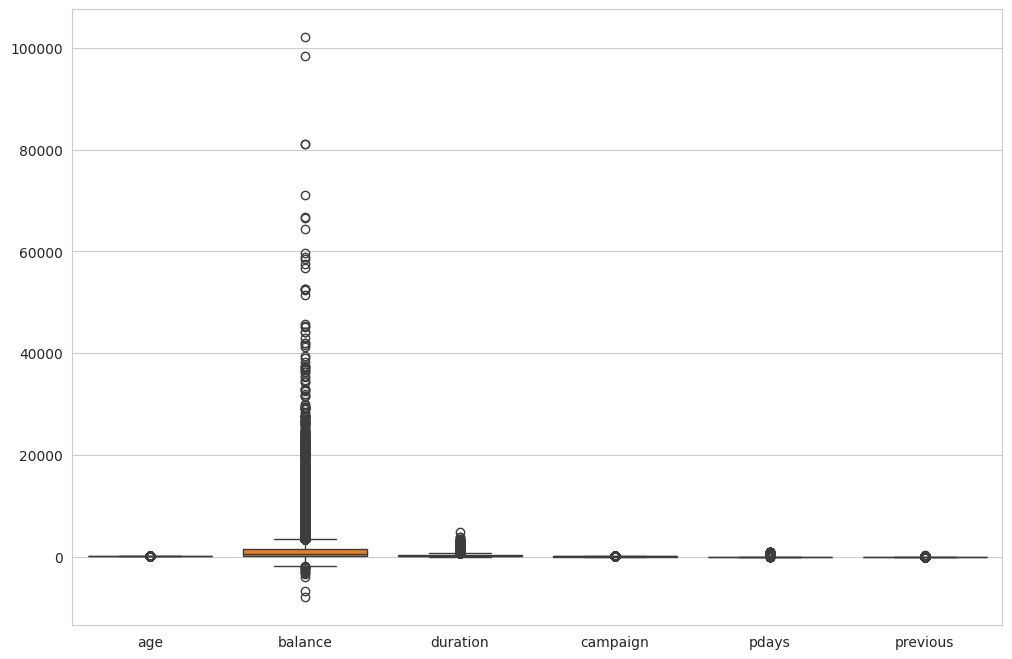

In [13]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df[['age','balance','duration','campaign','pdays','previous']])
plt.show()

# Analyse des boxplots des variables numériques

Les boxplots permettent de visualiser :

* la **médiane**
* l’**intervalle interquartile (IQR)**
* les **valeurs extrêmes (outliers)**.

On observe que plusieurs variables présentent **des distributions très asymétriques avec de nombreux outliers**.


# 1. Variable **age**

La variable `age` présente une dispersion relativement modérée.

* La majorité des observations se situe entre **environ 30 et 50 ans**.
* Quelques valeurs plus élevées apparaissent au-delà de **70 ans**, correspondant probablement à des clients retraités.

Cependant, ces valeurs restent **réalistes et cohérentes**, et ne semblent pas être des erreurs de saisie.


# 2. Variable **balance**

La variable `balance` présente **un très grand nombre d’outliers**.

On observe :

* une forte concentration de valeurs autour de montants relativement faibles
* de nombreuses valeurs extrêmement élevées pouvant dépasser **100 000**.

Cela confirme l’asymétrie observée précédemment dans l’histogramme.

**Interprétation :**

* la majorité des clients possède un solde modéré
* une petite proportion possède des soldes très élevés, ce qui génère ces valeurs extrêmes.

Ces outliers ne sont pas nécessairement des erreurs, car certains clients peuvent effectivement disposer de **capitaux importants**.


# 3. Variable **duration**

La variable `duration` présente également **des valeurs extrêmes**.

* La majorité des appels dure quelques minutes
* certains appels durent beaucoup plus longtemps.

Cela peut s’expliquer par :

* des clients très intéressés par l’offre
* des conversations prolongées avec les conseillers.

La durée d’appel est souvent **un indicateur fort de l’intérêt du client pour le produit proposé**.


# 4. Variable **campaign**

La variable `campaign` montre que :

* la plupart des clients sont contactés **un nombre limité de fois**
* certains cas extrêmes présentent un nombre de contacts beaucoup plus élevé.

Ces observations peuvent correspondre à des situations où la banque a tenté **plusieurs relances commerciales**.


# 5. Variables **pdays** et **previous**

Ces variables montrent également **une forte concentration autour de valeurs faibles**, avec quelques valeurs élevées.

Cela confirme que :

* la majorité des clients n’a **pas ou peu d’historique de campagne marketing**
* seuls quelques clients ont été contactés plusieurs fois dans le passé.


# Conclusion générale sur les outliers

L’analyse des boxplots met en évidence :

* la présence **d’outliers importants**, notamment pour les variables `balance` et `duration`
* une forte **asymétrie dans plusieurs distributions**.

Cependant, ces valeurs extrêmes semblent **cohérentes avec la nature des données bancaires et marketing**, et ne représentent pas nécessairement des erreurs.

Il conviendra néanmoins de **garder ces caractéristiques à l’esprit lors de la modélisation**, car certaines méthodes statistiques peuvent être sensibles aux valeurs extrêmes.

Maintenant, on va commencer l’analyse bivariée, c’est-à-dire étudier la relation entre les variables explicatives et la variable cible y.

C’est là que l’analyse devient vraiment intéressante.

On commence par une variable très importante : l’âge.

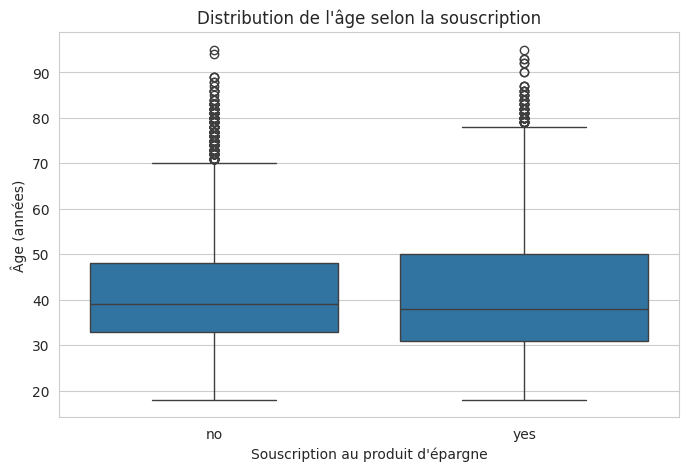

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='age', data=df)

plt.title("Distribution de l'âge selon la souscription")
plt.xlabel("Souscription au produit d'épargne")
plt.ylabel("Âge (années)")

plt.show()

# Analyse de la relation entre **l’âge et la souscription**

Le boxplot compare **la distribution de l’âge des clients selon qu’ils ont souscrit (`yes`) ou non (`no`) au produit d’épargne**.


## 1. Comparaison des médianes

La médiane de l’âge est **relativement similaire pour les deux groupes**.

* clients **n’ayant pas souscrit** : environ **39 ans**
* clients **ayant souscrit** : environ **37–38 ans**

Cela indique que **l’âge moyen des deux groupes est assez proche**.


## 2. Dispersion des âges

Les deux distributions présentent **une dispersion comparable** :

* la majorité des clients se situe entre **30 et 50 ans**
* ce qui correspond à la population active.

Cela confirme l’observation faite précédemment lors de l’analyse univariée.


## 3. Présence d’âges élevés

On observe plusieurs valeurs élevées (outliers) au-dessus de **70 ans**, notamment dans le groupe ayant souscrit.

Cela pourrait suggérer que **certains clients plus âgés sont également intéressés par des produits d’épargne**, ce qui est cohérent avec des profils proches de la retraite.


## 4. Interprétation générale

La comparaison visuelle montre que **l’âge seul ne semble pas être un facteur fortement discriminant** pour expliquer la souscription.

Les distributions des deux groupes sont **très proches**, ce qui suggère que d’autres variables, comme :

* la durée de l’appel
* la situation financière
* l’historique des campagnes

pourraient jouer un rôle plus important dans la décision du client.

# Conclusion de cette analyse

L’âge semble avoir **une influence relativement limitée** sur la décision de souscription.

Bien que certains clients plus âgés apparaissent dans le groupe ayant souscrit, la distribution globale reste **très similaire entre les deux groupes**.

Cela suggère que **l’âge seul n’est probablement pas un facteur déterminant dans la réussite de la campagne marketing**.

On va maintenant analyser la relation entre la durée de l’appel et la souscription, qui est souvent l’une des variables les plus influentes dans ce dataset.

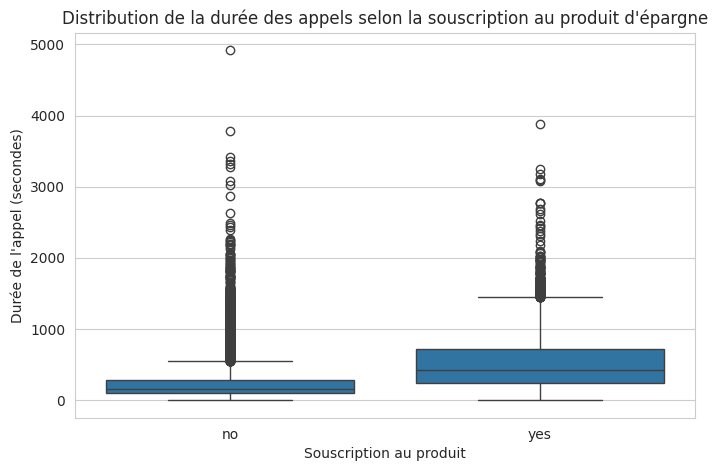

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='duration', data=df)

plt.title("Distribution de la durée des appels selon la souscription au produit d'épargne")
plt.xlabel("Souscription au produit")
plt.ylabel("Durée de l'appel (secondes)")

plt.show()

# Analyse de la relation entre la durée de l’appel et la souscription

Le boxplot compare **la durée des appels téléphoniques selon que le client a souscrit (`yes`) ou non (`no`) au produit d’épargne**.


# 1. Différence claire entre les deux groupes

On observe une **différence nette entre les distributions** :

* les clients **n’ayant pas souscrit** ont généralement des appels **plus courts**
* les clients **ayant souscrit** ont des appels **significativement plus longs**.

La médiane de la durée des appels est **beaucoup plus élevée pour les clients ayant souscrit**.

Cela suggère que **les appels plus longs sont associés à une probabilité plus élevée de souscription**.


# 2. Interprétation comportementale

Cette relation peut s’expliquer de manière logique :

* un client **peu intéressé** mettra fin rapidement à l’appel
* un client **intéressé par le produit** aura tendance à poser des questions et à discuter plus longtemps avec le conseiller.

La durée de l’appel peut donc être considérée comme **un indicateur indirect de l’intérêt du client**.


# 3. Présence d’outliers

On observe également **plusieurs valeurs extrêmes**, avec certains appels dépassant largement les **2000 secondes**.

Ces valeurs correspondent probablement à :

* des discussions approfondies avec des clients intéressés
* des situations où le conseiller explique en détail le produit financier.

Ces observations restent plausibles dans un contexte de relation client.


# 4. Importance de cette variable

La variable `duration` est connue pour être **l’une des variables les plus corrélées avec la souscription dans ce dataset**.

Cependant, il est important de noter que :

> la durée de l’appel n’est connue **qu’après avoir contacté le client**.

Cela signifie que cette variable ne peut pas être utilisée pour décider **quel client contacter à l’avance**.

Elle reste néanmoins très utile pour **comprendre le comportement des clients**.


# Conclusion de cette analyse

La durée de l’appel apparaît comme **un facteur fortement associé à la souscription**.

Les clients ayant souscrit au produit d’épargne ont en moyenne **des conversations plus longues avec les conseillers**, ce qui suggère que la durée de l’appel reflète **le niveau d’intérêt du client pour l’offre proposée**.

Maintenant on va analyser l’effet du solde bancaire (balance) sur la souscription.

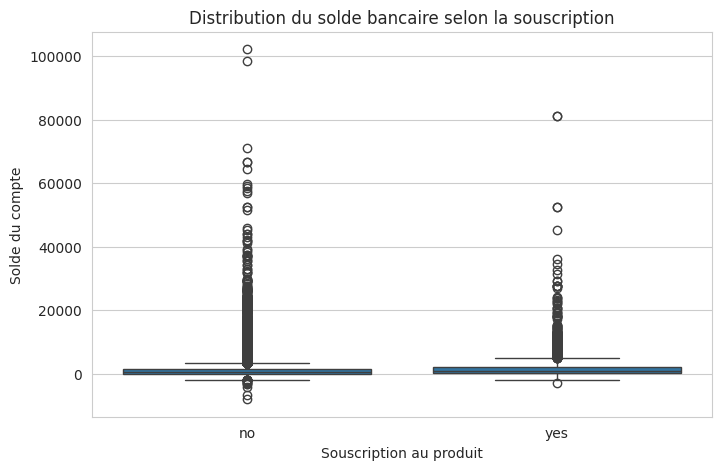

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='balance', data=df)

plt.title("Distribution du solde bancaire selon la souscription")
plt.xlabel("Souscription au produit")
plt.ylabel("Solde du compte")

plt.show()

# Analyse de la relation entre le solde bancaire et la souscription

Le boxplot compare **la distribution du solde bancaire des clients selon qu’ils ont souscrit (`yes`) ou non (`no`) au produit d’épargne**.


# 1. Tendance générale

On observe que :

* les clients ayant souscrit au produit d’épargne semblent avoir **un solde bancaire légèrement plus élevé en moyenne**
* la médiane du solde est **un peu plus élevée dans le groupe `yes` que dans le groupe `no`**.

Cela suggère que **les clients disposant d’un solde bancaire plus important pourraient être légèrement plus enclins à souscrire à un produit d’épargne**.

Cette observation est cohérente d’un point de vue économique :
les clients ayant davantage de liquidités sont généralement **plus susceptibles d’investir dans des produits financiers**.


# 2. Forte dispersion des valeurs

Cependant, la variable `balance` présente **une très forte dispersion**.

On observe :

* de nombreux **outliers positifs**, correspondant à des clients disposant de soldes très élevés
* quelques **soldes négatifs**, indiquant des situations de découvert bancaire.

Cette dispersion rend la comparaison visuelle **moins évidente que pour la variable `duration`**.


# 3. Influence des outliers

Les valeurs extrêmes (certains soldes dépassant **100 000**) tirent fortement la distribution vers le haut.

Ces outliers sont plausibles dans un contexte bancaire, car certains clients peuvent disposer **de capitaux importants**.

Cependant, ils peuvent **masquer les tendances générales dans les graphiques**.


# 4. Interprétation générale

Contrairement à la variable `duration`, la variable `balance` ne semble pas être **un facteur fortement discriminant à elle seule**.

Même si les clients ayant souscrit possèdent en moyenne un solde légèrement plus élevé, les distributions des deux groupes restent **relativement proches**.

Cela suggère que **le solde bancaire seul ne suffit pas à expliquer la décision de souscription**, et qu’il doit être analysé en combinaison avec d’autres variables.


# Conclusion

L’analyse du solde bancaire montre que :

* les clients ayant souscrit semblent disposer **légèrement plus de ressources financières**
* la variable présente **une forte dispersion avec de nombreux outliers**
* le solde bancaire pourrait jouer **un rôle secondaire dans la décision de souscription**.

On va maintenant analyser une variable catégorielle importante : la profession (job).

Cette analyse permet souvent d’identifier les catégories socio-professionnelles les plus réceptives aux campagnes marketing.

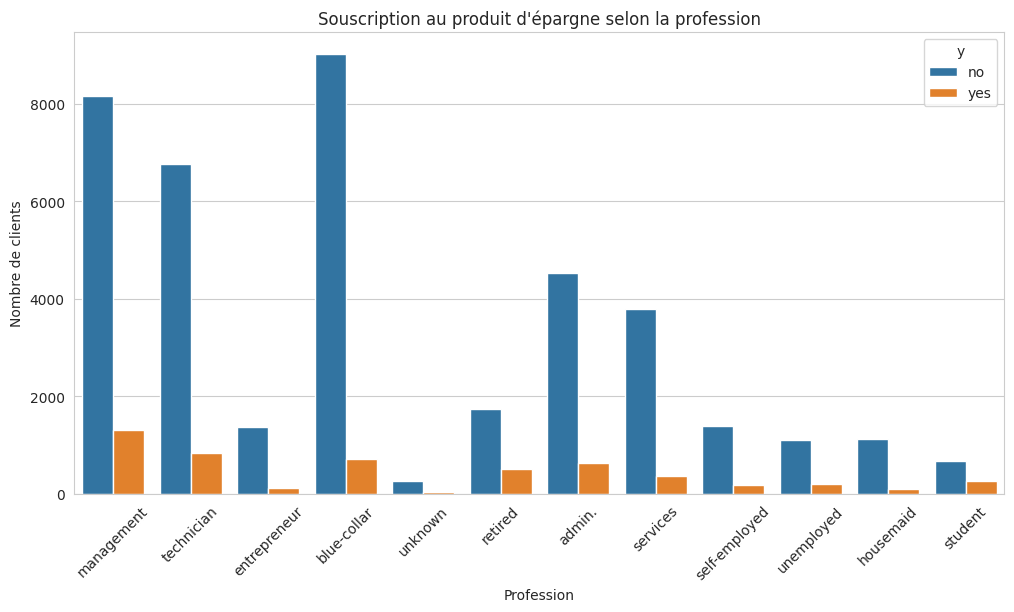

In [17]:
plt.figure(figsize=(12,6))

sns.countplot(x='job', hue='y', data=df)

plt.title("Souscription au produit d'épargne selon la profession")
plt.xlabel("Profession")
plt.ylabel("Nombre de clients")

plt.xticks(rotation=45)

plt.show()

# Analyse de la souscription selon la profession (`job`)

Ce graphique présente **le nombre de clients ayant souscrit ou non au produit d’épargne selon leur profession**.


## 1. Professions les plus représentées

On observe que certaines professions sont **beaucoup plus présentes dans le dataset**, notamment :

* **blue-collar**
* **management**
* **technician**
* **admin.**

Ces catégories représentent une grande partie des clients contactés par la banque.

Le nombre élevé de souscriptions dans ces groupes s’explique donc en partie par **leur forte présence dans les données**.


## 2. Professions avec le plus de souscriptions (en volume)

Les professions qui présentent le plus grand nombre de souscriptions sont :

* **management**
* **technician**
* **admin.**
* **blue-collar**

Cela peut s’expliquer par :

* une plus grande stabilité financière
* un accès plus régulier aux services bancaires.

Cependant, cette observation doit être interprétée **avec prudence**, car ces professions sont également **les plus nombreuses dans le dataset**.


## 3. Professions moins représentées

Certaines catégories apparaissent moins fréquemment, notamment :

* **student**
* **unemployed**
* **housemaid**
* **self-employed**

Le nombre de souscriptions y est naturellement plus faible, mais cela ne signifie pas nécessairement que ces groupes sont **moins intéressés par les produits d’épargne**.


## 4. Limite de cette visualisation

Ce graphique montre **le nombre total de souscriptions**, mais ne permet pas d’identifier directement **les professions ayant la plus forte probabilité de souscription**.

Pour une analyse plus pertinente, il serait préférable d’analyser **le taux de souscription par profession**, c’est-à-dire :

> la proportion de clients ayant souscrit dans chaque catégorie professionnelle.

Cela permettra d’identifier **les profils professionnels les plus réceptifs aux campagnes marketing**.


# Conclusion

L’analyse par profession montre que certaines catégories socio-professionnelles, comme **management, technician et admin**, comptent un nombre important de souscriptions.

Cependant, cette observation est en grande partie liée **au nombre élevé de clients appartenant à ces catégories dans le dataset**.

Pour une analyse plus précise, il sera nécessaire d’examiner **le taux de souscription par profession**.

Maintenant on va analyser le taux de souscription par profession, ce qui est bien plus informatif.

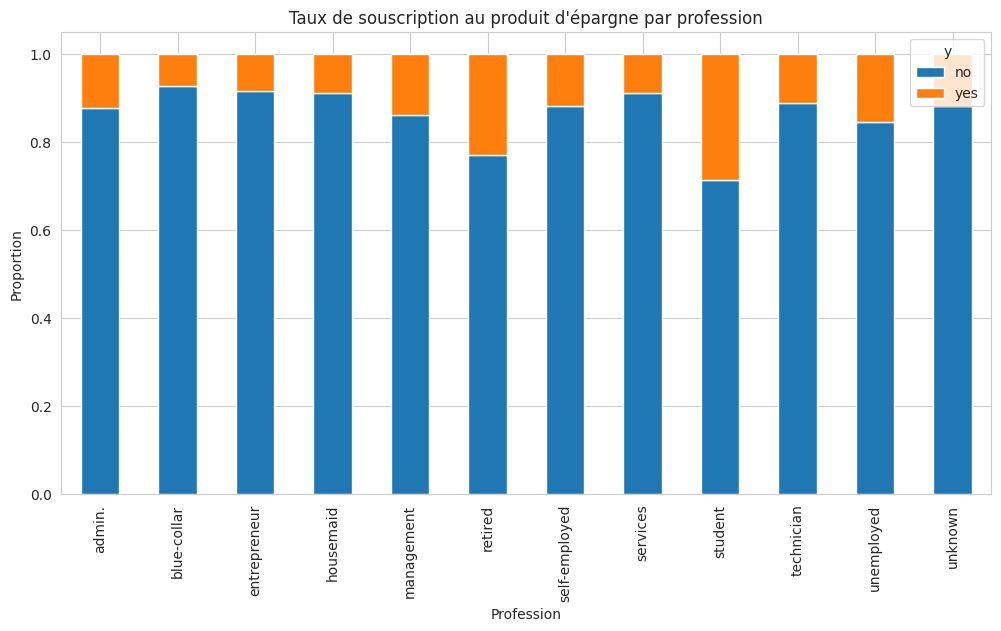

In [18]:
job_subscription_rate = pd.crosstab(df['job'], df['y'], normalize='index')

job_subscription_rate.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Taux de souscription au produit d'épargne par profession")
plt.xlabel("Profession")
plt.ylabel("Proportion")

plt.show()

# Analyse du taux de souscription selon la profession

Ce graphique représente **la proportion de clients ayant souscrit (`yes`) ou non (`no`) au produit d’épargne pour chaque catégorie professionnelle**.

Chaque barre correspond à **une profession**, et la partie orange indique **le taux de souscription**.


# 1. Professions avec le taux de souscription le plus élevé

On observe que certaines catégories présentent **un taux de souscription plus élevé que les autres**, notamment :

* **students**
* **retired**

Ces deux groupes présentent une proportion relativement plus importante de clients ayant souscrit au produit.

### Interprétation possible

* **students** peuvent être intéressés par des solutions d’épargne simples pour gérer leur budget ou commencer à épargner.
* **retired** disposent souvent d’une stabilité financière et peuvent être plus enclins à placer leur capital dans des produits d’épargne.


# 2. Professions avec un taux de souscription plus faible

Certaines catégories semblent présenter **un taux de souscription plus faible**, notamment :

* **blue-collar**
* **services**
* **entrepreneur**

Ces professions semblent être **moins réceptives aux campagnes marketing pour les produits d’épargne**.

Cela peut être lié à :

* des revenus plus variables
* une priorité donnée à d’autres besoins financiers.


# 3. Professions avec un taux intermédiaire

Certaines professions présentent **un taux de souscription relativement intermédiaire**, par exemple :

* **management**
* **admin.**
* **technician**

Ces groupes représentent souvent **la population active avec une situation financière relativement stable**, ce qui peut expliquer un niveau modéré d’intérêt pour les produits d’épargne.


# 4. Observation générale

Malgré les différences observées, on constate que **la majorité des clients dans chaque profession n’ont pas souscrit au produit**.

Cela confirme l’observation faite précédemment sur la variable cible :
le dataset est **fortement déséquilibré**, avec une majorité de réponses négatives.


# Conclusion

L’analyse du taux de souscription selon la profession suggère que **certaines catégories socio-professionnelles, comme les étudiants et les retraités, semblent plus réceptives aux campagnes marketing pour les produits d’épargne**.

À l’inverse, d’autres professions présentent **des taux de souscription plus faibles**, ce qui pourrait refléter des différences dans les priorités financières ou la capacité d’épargne.

Ces observations pourraient aider la banque à **cibler plus efficacement certains profils de clients lors de futures campagnes marketing**.

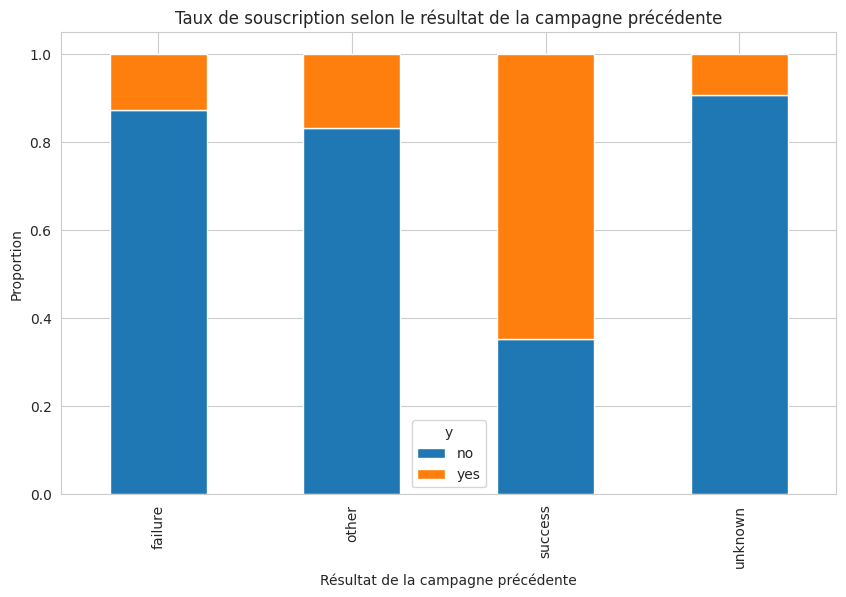

In [19]:
poutcome_rate = pd.crosstab(df['poutcome'], df['y'], normalize='index')

poutcome_rate.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Taux de souscription selon le résultat de la campagne précédente")
plt.xlabel("Résultat de la campagne précédente")
plt.ylabel("Proportion")

plt.show()

# Analyse du taux de souscription selon le résultat de la campagne précédente (`poutcome`)

Ce graphique présente **la proportion de clients ayant souscrit ou non au produit d’épargne selon le résultat de la campagne marketing précédente**.

Les catégories observées sont :

* **success** : la campagne précédente a réussi
* **failure** : la campagne précédente a échoué
* **other** : autre résultat
* **unknown** : aucun historique ou information non disponible


# 1. Impact très fort d’un succès précédent

La catégorie **success** se distingue très clairement des autres.

On observe que **la proportion de souscriptions est nettement plus élevée lorsque la campagne précédente a été un succès**.

Cela signifie que :

* les clients ayant déjà souscrit à un produit lors d’une campagne précédente sont **beaucoup plus susceptibles de souscrire à nouveau**.

### Interprétation marketing

Ce résultat est logique : un client qui a déjà répondu positivement à une offre bancaire a probablement :

* une relation de confiance avec la banque
* un intérêt pour les produits financiers.

Ces clients constituent donc **une cible particulièrement intéressante pour les campagnes futures**.


# 2. Faible taux de souscription après un échec

Dans la catégorie **failure**, la proportion de clients ayant souscrit est **beaucoup plus faible**.

Cela suggère que :

* les clients ayant refusé une offre dans le passé ont **moins de chances de répondre positivement à une nouvelle sollicitation**.

Cela peut refléter :

* un manque d’intérêt pour ce type de produit
* une certaine saturation face aux sollicitations commerciales.


# 3. Catégorie "unknown"

La catégorie **unknown** représente les clients pour lesquels **aucune information sur une campagne précédente n’est disponible**.

Le taux de souscription dans ce groupe reste **relativement faible**, ce qui est cohérent avec le fait que ces clients n’ont probablement **jamais été contactés auparavant**.


# 4. Catégorie "other"

La catégorie **other** présente un taux de souscription **légèrement supérieur à celui de "failure"**, mais inférieur à celui de "success".

Cette catégorie regroupe probablement **des situations particulières ou ambiguës dans l’historique des campagnes**.


# Conclusion

L’analyse de la variable `poutcome` montre que **l’historique des campagnes marketing est un facteur très important dans la probabilité de souscription**.

Les clients ayant déjà répondu positivement à une campagne précédente présentent **une probabilité nettement plus élevée de souscrire à nouveau**, ce qui suggère que la banque pourrait optimiser ses campagnes en **ciblant prioritairement ces clients**.

Cette variable apparaît donc comme **un indicateur clé du comportement des clients face aux offres marketing**.


On va analyser l’impact du prêt immobilier (housing) sur la souscription.

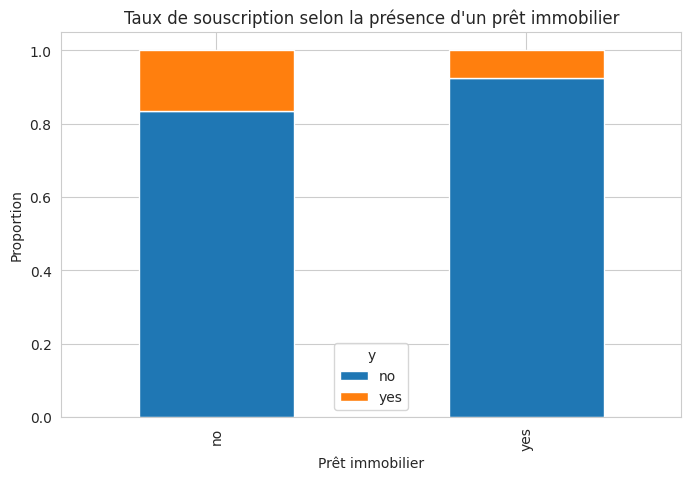

In [20]:
housing_rate = pd.crosstab(df['housing'], df['y'], normalize='index')

housing_rate.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Taux de souscription selon la présence d'un prêt immobilier")
plt.xlabel("Prêt immobilier")
plt.ylabel("Proportion")

plt.show()

# Analyse du taux de souscription selon la présence d’un prêt immobilier (`housing`)

Ce graphique représente **la proportion de clients ayant souscrit ou non au produit d’épargne selon qu’ils possèdent un prêt immobilier**.

Les deux catégories étudiées sont :

* **yes** : le client possède un prêt immobilier
* **no** : le client ne possède pas de prêt immobilier.


# 1. Différence observable entre les deux groupes

On observe que **les clients ne possédant pas de prêt immobilier présentent un taux de souscription plus élevé** que ceux ayant un prêt immobilier.

Autrement dit :

* les clients **sans prêt immobilier** semblent être **plus enclins à souscrire au produit d’épargne**
* les clients **ayant un prêt immobilier** souscrivent moins fréquemment.


# 2. Interprétation économique

Cette différence peut s’expliquer par plusieurs facteurs financiers.

Les clients ayant un prêt immobilier doivent généralement :

* rembourser des mensualités importantes
* consacrer une part significative de leurs revenus au remboursement du crédit.

Cela peut réduire leur **capacité d’épargne disponible**, ce qui peut expliquer leur **moindre intérêt pour un produit d’épargne supplémentaire**.

À l’inverse, les clients sans prêt immobilier disposent souvent **d’une plus grande flexibilité financière**, ce qui peut favoriser leur décision d’investir dans un produit d’épargne.


# 3. Importance de cette variable

La variable `housing` semble donc apporter **une information pertinente sur la situation financière des clients**.

Même si la différence observée n’est pas extrêmement forte, elle suggère que **le niveau d’endettement lié au logement peut influencer le comportement d’épargne**.


# Conclusion

L’analyse montre que les clients **sans prêt immobilier présentent une probabilité légèrement plus élevée de souscrire au produit d’épargne**.

Cette observation suggère que **la situation financière et le niveau d’endettement des clients peuvent influencer leur décision de souscription**.

On va analyser l’impact du prêt personnel (loan) sur la souscription, ce qui permet de compléter l’analyse du niveau d’endettement des clients.

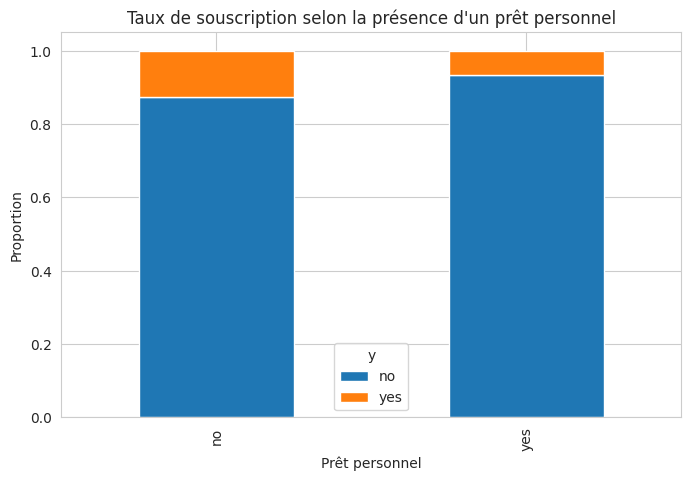

In [21]:
loan_rate = pd.crosstab(df['loan'], df['y'], normalize='index')

loan_rate.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title("Taux de souscription selon la présence d'un prêt personnel")
plt.xlabel("Prêt personnel")
plt.ylabel("Proportion")

plt.show()

# Analyse du taux de souscription selon la présence d’un prêt personnel (`loan`)

Ce graphique montre **la proportion de clients ayant souscrit ou non au produit d’épargne selon qu’ils possèdent un prêt personnel**.

Les deux catégories étudiées sont :

* **yes** : le client possède un prêt personnel
* **no** : le client ne possède pas de prêt personnel.


# 1. Différence entre les deux groupes

On observe que :

* les clients **sans prêt personnel** présentent un **taux de souscription plus élevé**
* les clients **ayant un prêt personnel** souscrivent **moins souvent** au produit d’épargne.

La proportion de réponses positives est donc **plus faible lorsque le client possède déjà un crédit personnel**.


# 2. Interprétation financière

Ce résultat peut s’expliquer par la situation financière des clients.

Un prêt personnel implique généralement :

* des **remboursements mensuels**
* une **réduction du revenu disponible**
* une priorité donnée au remboursement du crédit.

Dans ce contexte, les clients ayant un prêt personnel peuvent être **moins enclins à placer de l’argent dans un produit d’épargne**.

À l’inverse, les clients sans prêt personnel disposent souvent **d’une capacité d’épargne plus importante**, ce qui peut favoriser leur décision de souscrire.


# 3. Comparaison avec le prêt immobilier

Ce résultat est cohérent avec l’analyse précédente sur le **prêt immobilier**.

Dans les deux cas, on observe que :

> **les clients ayant moins de dettes semblent plus susceptibles de souscrire à un produit d’épargne**.

Cela confirme que **la situation d’endettement est un facteur potentiel dans la décision d’investissement financier**.


# Conclusion

L’analyse montre que les clients **sans prêt personnel présentent une probabilité plus élevée de souscrire au produit d’épargne**.

Cela suggère que **la capacité financière et le niveau d’endettement des clients peuvent influencer leur comportement face aux offres d’épargne**.

Pour terminer proprement l’EDA, on peut analyser la saisonnalité des campagnes marketing avec la variable

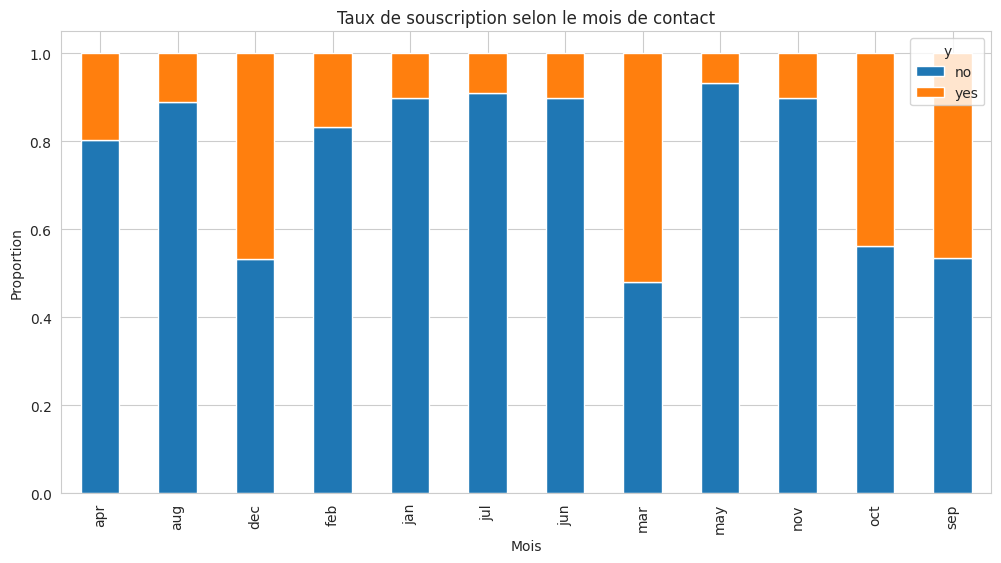

In [22]:
month_rate = pd.crosstab(df['month'], df['y'], normalize='index')

month_rate.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Taux de souscription selon le mois de contact")
plt.xlabel("Mois")
plt.ylabel("Proportion")

plt.show()

# Analyse du taux de souscription selon le mois de contact (`month`)

Ce graphique présente **la proportion de clients ayant souscrit ou non au produit d’épargne selon le mois durant lequel ils ont été contactés**.

Chaque barre représente **le taux de souscription pour un mois donné**.


# 1. Variabilité du taux de souscription selon les mois

On observe que **le taux de souscription varie fortement selon les mois**.

Certains mois présentent **une proportion plus élevée de souscriptions**, notamment :

* **mars**
* **septembre**
* **octobre**
* **décembre**

Ces mois semblent être **plus favorables aux campagnes marketing pour les produits d’épargne**.


# 2. Mois avec un taux de souscription plus faible

D’autres mois présentent un taux de souscription **plus faible**, notamment :

* **mai**
* **janvier**
* **juillet**
* **août**

Cela suggère que les campagnes menées pendant ces périodes pourraient être **moins efficaces**.


# 3. Interprétation possible : effet saisonnier

Ces variations peuvent être liées à **des facteurs saisonniers**.

Par exemple :

* à la fin de l’année (**septembre – décembre**), les clients peuvent être plus enclins à **organiser leur épargne**
* certaines périodes de l’année peuvent correspondre à **des moments où les clients disposent de plus de liquidités**.

À l’inverse, durant certaines périodes (vacances ou début d’année), les clients peuvent être **moins réceptifs aux offres financières**.


# 4. Implication pour la stratégie marketing

Ces résultats suggèrent que :

> **le moment de l’année peut influencer l’efficacité des campagnes marketing**.

La banque pourrait donc optimiser ses campagnes en :

* intensifiant les actions marketing durant les périodes **où le taux de souscription est plus élevé**
* ajustant ses stratégies durant les périodes moins favorables.


# Conclusion

L’analyse du mois de contact met en évidence **une variation du taux de souscription selon la période de l’année**, ce qui suggère l’existence **d’un effet saisonnier dans la réussite des campagnes marketing**.

Le timing des campagnes pourrait donc constituer **un levier stratégique pour améliorer leur efficacité**.

# Synthèse des principaux insights de l’EDA

## 1. Forte asymétrie de la variable cible

L’analyse de la variable cible montre que **la majorité des clients ne souscrivent pas au produit d’épargne**.

Environ :

* **88 % des clients n’ont pas souscrit**
* **12 % ont souscrit**

Ce déséquilibre est caractéristique des campagnes marketing : seule une minorité de clients accepte l’offre proposée.
Cela implique que l’évaluation des modèles devra utiliser **des métriques adaptées aux datasets déséquilibrés**.


# 2. La durée de l’appel est fortement liée à la souscription

La variable **duration** apparaît comme **l’un des facteurs les plus discriminants**.

Les clients ayant souscrit au produit d’épargne ont généralement **des appels beaucoup plus longs** que ceux qui n’ont pas souscrit.

Cela suggère que :

* un appel prolongé peut refléter **un intérêt plus important du client**
* les interactions plus longues avec les conseillers augmentent la probabilité de conversion.

Cependant, cette variable doit être utilisée avec prudence car elle n’est **connue qu’après l’appel**.


# 3. L’historique des campagnes marketing joue un rôle majeur

La variable **poutcome** (résultat de la campagne précédente) montre un effet très marqué.

Les clients ayant déjà eu **un résultat positif lors d’une campagne précédente** présentent **un taux de souscription beaucoup plus élevé**.

Cela indique que :

* les clients ayant déjà répondu positivement à une offre bancaire sont **plus susceptibles de souscrire à nouveau**
* ces clients constituent **une cible prioritaire pour les campagnes futures**.


# 4. La situation d’endettement influence le comportement d’épargne

Les variables **housing** (prêt immobilier) et **loan** (prêt personnel) montrent que :

* les clients **sans prêt** ont tendance à souscrire **plus fréquemment**
* les clients **ayant des crédits** souscrivent moins souvent.

Cela peut s’expliquer par :

* une capacité d’épargne plus limitée
* une priorité donnée au remboursement des dettes.


# 5. Certaines professions semblent plus réceptives aux offres d’épargne

L’analyse du taux de souscription par profession montre que certaines catégories, notamment :

* **students**
* **retired**

présentent un taux de souscription relativement plus élevé.

Ces groupes pourraient donc représenter **des segments intéressants pour les campagnes marketing**.


# 6. Le moment de l’année semble influencer la réussite des campagnes

L’analyse de la variable **month** met en évidence **des variations du taux de souscription selon le mois de contact**.

Certains mois présentent **un taux de conversion plus élevé**, ce qui suggère un possible **effet saisonnier dans la réussite des campagnes marketing**.

Cela signifie que le **timing des campagnes peut influencer leur efficacité**.


# 7. L’âge et le solde bancaire ne semblent pas être des facteurs très discriminants

Contrairement à certaines variables précédentes :

* **l’âge**
* **le solde bancaire**

ne montrent pas de différence très marquée entre les clients ayant souscrit et ceux n’ayant pas souscrit.

Cela suggère que ces variables, prises isolément, **n’expliquent pas fortement la décision de souscription**.


# Conclusion générale de l’EDA

L’analyse exploratoire a permis d’identifier plusieurs facteurs potentiellement liés à la souscription au produit d’épargne.

Les variables les plus prometteuses semblent être :

* **duration**
* **poutcome**
* **housing**
* **loan**
* **job**
* **month**

Ces variables seront particulièrement intéressantes pour **la construction des modèles de classification dans la phase suivante du projet**.